# World Bank Data: What Drives GDP per Capita?

This project uses World Bank indicators (2010–2024) to explore how **GDP per capita** relates to development factors (health, education, connectivity, infrastructure, etc.).

We follow **CRISP-DM**:
1) Business Understanding  
2) Data Understanding  
3) Data Preparation  
4) Modeling  
5) Evaluation  
6) Communication (GitHub + Blog)

In [16]:
"""
World Bank Economy & Development Drivers
CRISP-DM notebook for Udacity Data Science Nanodegree project.

Author: Gautam Prasad
"""

from __future__ import annotations

import warnings
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## 1) Business Understanding (CRISP-DM)

**Target outcome:** `GDP per capita (current US$)`

We will answer **4 business questions** using this analysis

1. **Which indicators are most strongly associated with GDP per capita?**  
2. **How do infrastructure and connectivity relate to GDP per capita?**  
   (Focus: internet usage + electricity access)  
3. **Which countries appear as “outliers”** (high GDP per capita but weaker outcomes like low life expectancy or high unemployment)?  
4. **Can we predict GDP per capita from these indicators** and use the model in a **creative predictive scenario**?

> Note: Correlation and prediction do not prove causation. The goal is to identify patterns and build an illustrative predictive model.

## 2) Data Understanding

The dataset is a typical World Bank export format:

- Each row is a **(country, indicator)** pair  
- Each year is a separate column (e.g., `2010 [YR2010]`)  

We will:
1) convert to a long format (country–indicator–year), then  
2) pivot into a modeling table: rows = **(country, year)**, columns = **indicators**

In [3]:
# Data read
raw = pd.read_csv("world_bank_data.csv")
raw.head()

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,14.3624414710737,0.426354776777345,12.7522870926697,5.60074465863221,2.72454336219565,1.45131466066431,2.26031420279821,2.6470032027451,1.18922812944517,3.91160341625552,-2.35110067203466,-20.7388393676343,-6.24017199240269,2.26694373649188,..
1,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,560.621505463146,606.694676337726,651.417134470046,637.087099117099,625.054941813938,565.569730408751,522.082215583898,525.469770891619,491.337221382603,496.6025042585,510.787063366811,356.496214115892,357.261152798144,413.757894705303,..
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,28284089,29347708,30560034,31622704,32792523,33831764,34700612,35688935,36743039,37856121,39068979,40000412,40578842,41454761,42647492
3,Afghanistan,AFG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,3.4794499874115,3.4620099067688,2.60419988632202,3.45445990562439,3.69521999359131,3.2558000087738,4.54397010803223,4.34319019317627,..,..,..,..,..,..,..
4,Afghanistan,AFG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,8.56967163,8.56190777,7.89716864,8.80596447,9.52887821,10.10534763,11.81859016,12.62081718,14.20841885,14.83131981,15.53361416,21.508461,23.0881691,..,..


In [17]:
# Functions to clean up data

def get_year_columns(df: pd.DataFrame) -> List[str]:
    """
    Identify World Bank year columns such as '2010 [YR2010]'.

    Args:
        df: Raw World Bank export dataframe.

    Returns:
        List of year column names.
    """
    return [c for c in df.columns if isinstance(c, str) and c.endswith("]")]


def tidy_world_bank_export(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert World Bank export format into a tidy long table:
    one row per country-indicator-year.

    Args:
        df: Raw World Bank export dataframe.

    Returns:
        Tidy dataframe with columns:
        ['Country Name','Country Code','Series Name','Series Code','Year','Value']
    """
    df = df.dropna(subset=["Country Name", "Series Name"]).copy()
    year_cols = get_year_columns(df)

    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
        value_vars=year_cols,
        var_name="Year",
        value_name="Value",
    )

    long_df["Year"] = long_df["Year"].str.extract(r"(\d{4})").astype(int)
    long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")
    return long_df


long = tidy_world_bank_export(raw)
long.head()

,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2010,1.436244e+01
1,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2010,5.606215e+02
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2010,2.828409e+07
3,Afghanistan,AFG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,2010,3.479450e+00
4,Afghanistan,AFG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,2010,8.569672e+00


In [18]:
# Functions to pivot

def pivot_to_country_year(df_long: pd.DataFrame) -> pd.DataFrame:
    """
    Pivot tidy long table into wide modeling table:
    rows = (country, year), columns = indicators.

    Args:
        df_long: Tidy long dataframe.

    Returns:
        Wide dataframe: ['Country Name','Country Code','Year', <indicator columns...>]
    """
    wide_df = df_long.pivot_table(
        index=["Country Name", "Country Code", "Year"],
        columns="Series Name",
        values="Value",
        aggfunc="mean",
    ).reset_index()

    wide_df.columns.name = None
    return wide_df


wide = pivot_to_country_year(long)
wide.head()

,Country Name,Country Code,Year,Access to electricity (% of population),Current health expenditure (% of GDP),GDP growth (annual %),GDP per capita (current US$),"Government expenditure on education, total (% of GDP)",Gross fixed capital formation (% of GDP),Individuals using the Internet (% of population),"Life expectancy at birth, total (years)","Population, total","School enrollment, primary (% gross)","School enrollment, secondary (% gross)",Trade (% of GDP),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
0,Afghanistan,AFG,2010,42.7,8.569672,14.362441,560.621505,3.47945,NaN,4.00000,60.702,28284089.0,103.485603,50.440620,NaN,7.753,23.737
1,Afghanistan,AFG,2011,43.2,8.561908,0.426355,606.694676,3.46201,NaN,5.00000,61.250,29347708.0,101.542084,52.447430,NaN,7.784,23.948
2,Afghanistan,AFG,2012,69.1,7.897169,12.752287,651.417134,2.60420,NaN,5.45455,61.735,30560034.0,106.575317,54.372860,NaN,7.856,24.160
3,Afghanistan,AFG,2013,68.0,8.805964,5.600745,637.087099,3.45446,NaN,5.90000,62.188,31622704.0,107.942841,54.883369,NaN,7.930,24.373
4,Afghanistan,AFG,2014,89.5,9.528878,2.724543,625.054942,3.69522,NaN,7.00000,62.260,32792523.0,109.829453,54.293652,NaN,7.915,24.587


## 3) Data Preparation (Cleaning + Missing Values)

We will:
- quantify missingness
- keep the data in a form suitable for both EDA and modeling
- handle missing values using imputation **inside the ML pipeline**
  (median for numeric, most-frequent for categorical)

In [6]:
# Identify missing values
missing_rate = wide.isna().mean().sort_values(ascending=False)
missing_rate.head(15)

School enrollment, secondary (% gross)                                 0.352074
Government expenditure on education, total (% of GDP)                  0.317665
School enrollment, primary (% gross)                                   0.259293
Current health expenditure (% of GDP)                                  0.232873
Gross fixed capital formation (% of GDP)                               0.231029
Trade (% of GDP)                                                       0.176037
Individuals using the Internet (% of population)                       0.152995
Unemployment, total (% of total labor force) (modeled ILO estimate)    0.141014
Access to electricity (% of population)                                0.075269
Life expectancy at birth, total (years)                                0.066667
dtype: float64

## 4) Exploratory Data Analysis (EDA)

### Why Spearman correlation?
GDP per capita and many indicators are skewed and may have outliers. **Spearman** correlation
measures monotonic relationships using ranks, making it more robust than Pearson in this setting.

### Why log scale for GDP per capita charts?
GDP per capita has a heavy right-skew. Using a **log scale** makes patterns clearer across low-
and high-income ranges.

### Question 1: Which indicators are most strongly associated with GDP per capita?

We compute Spearman correlation between GDP per capita and every numeric indicator.
We then rank by **absolute** correlation magnitude.

In [19]:
target = "GDP per capita (current US$)"

# Spearman correlation with GDP per capita
corrs = (
    wide.select_dtypes(include=[np.number])
        .corr(method="spearman")[target]
        .drop(target)
)

# Sort by absolute correlation (pandas-version safe, no `key=` arg)
corrs = corrs.reindex(corrs.abs().sort_values(ascending=False).index)

corrs.head(10)

Life expectancy at birth, total (years)                  0.862753
Individuals using the Internet (% of population)         0.836873
Access to electricity (% of population)                  0.835576
School enrollment, secondary (% gross)                   0.757667
Urban population (% of total population)                 0.687526
Trade (% of GDP)                                         0.389756
Current health expenditure (% of GDP)                    0.345538
Population, total                                       -0.312969
GDP growth (annual %)                                   -0.232939
Government expenditure on education, total (% of GDP)    0.196661
Name: GDP per capita (current US$), dtype: float64

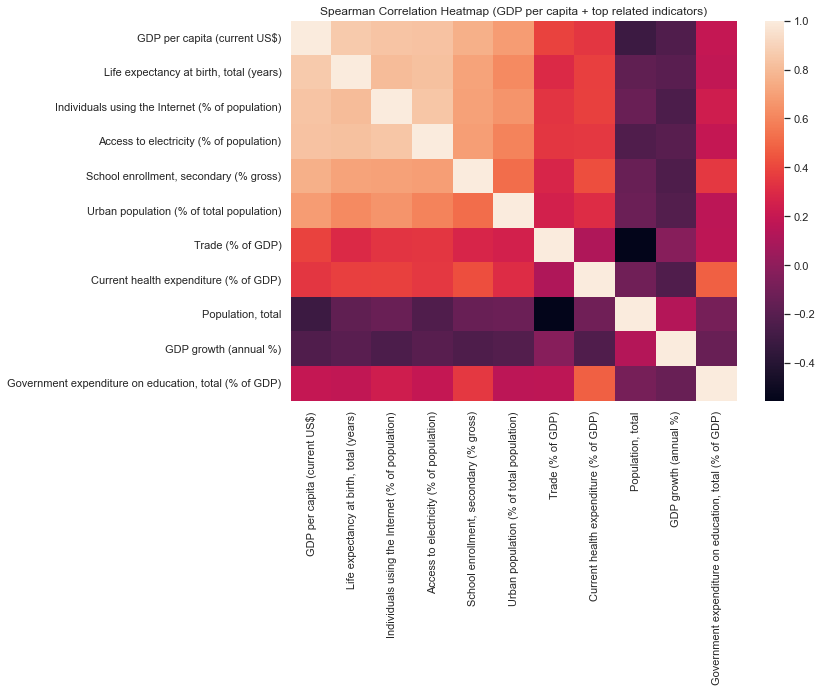

In [20]:
top_k = list(corrs.head(10).index)
cols = [target] + top_k

plt.figure(figsize=(10, 7))
sns.heatmap(wide[cols].corr(method="spearman"), annot=False)
plt.title("Spearman Correlation Heatmap (GDP per capita + top related indicators)")
plt.show()

### Question 2: Infrastructure & Connectivity vs GDP per capita

We focus on:
- Individuals using the Internet (% of population)
- Access to electricity (% of population)

GDP per capita is shown on a **log scale** to reveal trends across the full range.

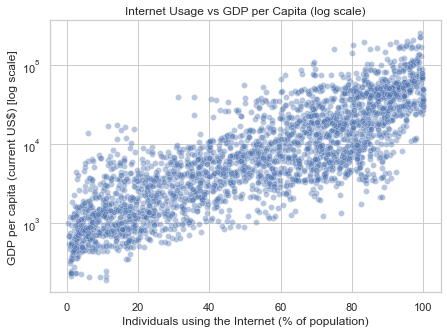

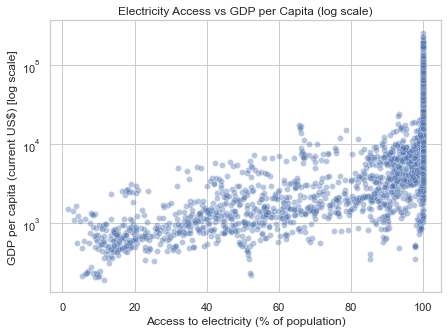

In [21]:
# Plotting usage/access vs GDP

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=wide,
    x="Individuals using the Internet (% of population)",
    y=target,
    alpha=0.4,
)
plt.yscale("log")
plt.title("Internet Usage vs GDP per Capita (log scale)")
plt.xlabel("Individuals using the Internet (% of population)")
plt.ylabel("GDP per capita (current US$) [log scale]")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=wide,
    x="Access to electricity (% of population)",
    y=target,
    alpha=0.4,
)
plt.yscale("log")
plt.title("Electricity Access vs GDP per Capita (log scale)")
plt.xlabel("Access to electricity (% of population)")
plt.ylabel("GDP per capita (current US$) [log scale]")
plt.show()

**Interpretation note (from the plot):**
Electricity access often clusters near 100% (a saturation effect). This suggests it may act
like a threshold indicator: once near-universal, it becomes less informative for separating
high-income countries from each other, while still distinguishing low-access contexts.

### Question 3: Outliers (interesting cases)

In the latest year of this extract, some indicators (e.g., life expectancy) can be missing
for many countries. To avoid misleading results, we compute outliers using the **latest year
with sufficient coverage** for the required indicators.

We flag observations that combine:
- high GDP per capita
- low life expectancy and/or high unemployment

This is a heuristic to surface “interesting” cases for deeper research.

In [22]:
def z_score(series: pd.Series) -> pd.Series:
    """Compute z-score while preserving NaNs."""
    return (series - series.mean()) / series.std()


latest_year = int(wide["Year"].max())
latest = wide[wide["Year"] == latest_year].copy()

latest["log_gdp_pc"] = np.log10(latest[target])

life_col = "Life expectancy at birth, total (years)"
unemp_col = "Unemployment, total (% of total labor force) (modeled ILO estimate)"

# Build an outlier score (higher = more "interesting" by this definition)
latest["outlier_score"] = (
    z_score(latest["log_gdp_pc"]).fillna(0)
    - z_score(latest[life_col]).fillna(0)
    + z_score(latest[unemp_col]).fillna(0)
)

latest.sort_values("outlier_score", ascending=False)[
    ["Country Name", "Year", target, life_col, unemp_col, "outlier_score"]
].head(15)

,Country Name,Year,GDP per capita (current US$),"Life expectancy at birth, total (years)","Unemployment, total (% of total labor force) (modeled ILO estimate)",outlier_score
2669,South Africa,2024,6253.371582,NaN,33.168,4.575462
959,Eswatini,2024,3936.109692,NaN,34.400,4.476016
389,Botswana,2024,7695.242064,NaN,23.138,2.911041
824,Djibouti,2024,3496.471119,NaN,25.875,2.856554
1064,Gabon,2024,8218.763071,NaN,20.061,2.401935
2774,St. Vincent and the Grenadines,2024,11501.226519,NaN,18.056,2.273845
329,Bermuda,2024,138934.958846,NaN,NaN,1.973913
1709,Libya,2024,6318.403140,NaN,18.615,1.958528
3224,"Yemen, Rep.",2024,NaN,NaN,17.086,1.855895
2699,Spain,2024,35297.009500,NaN,11.394,1.851580


## 5) Modeling (CRISP-DM)

**Target:** GDP per capita (current US$)  
We predict **log10(GDP per capita)** because GDP values are highly skewed.

**Model:** RandomForestRegressor  
Why:
- captures non-linear patterns
- robust to outliers
- supports feature importance for interpretability

**Categorical handling:** We include only `Country Code` (not both name and code) to avoid redundancy.
Country identifiers improve predictive performance, so we interpret results carefully and avoid causal claims.

In [23]:
# Modelling pipeline

model_df = wide.dropna(subset=[target]).copy()
model_df["log_target"] = np.log10(model_df[target])

X = model_df.drop(columns=[target, "log_target"])
y = model_df["log_target"]

cat_cols = ["Country Name", "Country Code"]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ],
    remainder="drop",
)

model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model),
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Year',
                                                   'Access to electricity (% '
                                                   'of population)',
                                                   'Current health expenditure '
                                                   '(% of GDP)',
                                                   'GDP growth (annual %)',
                                                   'Government expenditure on '
                                                   'education, total (% of '
                                                   'GDP)',
                                                   'Gross fixed capital '
                                                   'formation (% of GDP)',
                                  

In [24]:
# Predictions

pred = pipe.predict(X_test)

rmse = mean_squared_error(y_test, pred, squared=False)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"RMSE (log10 USD): {rmse:.6f}")
print(f"MAE  (log10 USD): {mae:.6f}")
print(f"R2:              {r2:.6f}")

# Convert log10 error into an approximate multiplicative factor:
# 10^rmse ≈ typical multiplicative error
print(f"Typical multiplicative error (RMSE): x{10**rmse:.2f}")
print(f"Average multiplicative error (MAE):  x{10**mae:.2f}")

RMSE (log10 USD): 0.112356
MAE  (log10 USD): 0.064585
R2:              0.968776
Typical multiplicative error (RMSE): x1.30
Average multiplicative error (MAE):  x1.16


### Model performance and interpretation

The Random Forest regression model was evaluated on a held-out test set.

- **RMSE (log10 GDP per capita): 0.112**
- **MAE (log10 GDP per capita): 0.065**
- **R²: 0.969**

Because the target variable was log-transformed, these errors can be interpreted
multiplicatively. An RMSE of approximately 0.11 corresponds to predictions typically
within about **±30%** of the true GDP per capita, while the MAE corresponds to an
average error of about **±16%**.

The high R² value indicates that the model explains a large share of the variation
in GDP per capita across countries and years. This suggests that the included
development indicators collectively provide strong predictive signal, though
this does not imply causation.

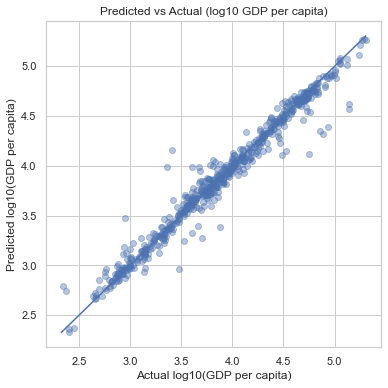

In [25]:
# Predicted vs Actual plot (helps reviewers see model quality quickly)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.4)
plt.title("Predicted vs Actual (log10 GDP per capita)")
plt.xlabel("Actual log10(GDP per capita)")
plt.ylabel("Predicted log10(GDP per capita)")

# Diagonal reference line
min_v = min(y_test.min(), pred.min())
max_v = max(y_test.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v])

plt.show()

### Feature Importance (interpretability)

We use Random Forest feature importances to identify which numeric indicators were most useful for prediction.
These importances reflect predictive utility in this dataset and **do not imply causation**.

In [27]:
def get_feature_importance(
    fitted_pipeline: Pipeline,
    numeric_features: list,
    categorical_features: list
) -> pd.Series:
    """
    Extract feature importances from a fitted pipeline with OneHotEncoder.

    Args:
        fitted_pipeline: Fitted sklearn Pipeline (preprocess + model)
        numeric_features: List of numeric feature names
        categorical_features: List of categorical feature names

    Returns:
        Pandas Series of feature importances sorted descending
    """
    
    pre = fitted_pipeline.named_steps["preprocess"]
    rf = fitted_pipeline.named_steps["model"]

    ohe = pre.named_transformers_["cat"].named_steps["onehot"]

    # ---- version-safe feature name extraction ----
    try:
        # Newer sklearn
        cat_names = list(ohe.get_feature_names_out(categorical_features))
    except AttributeError:
        # Older sklearn (Python 3.8 compatible)
        cat_names = list(ohe.get_feature_names(categorical_features))

    all_feature_names = numeric_features + cat_names
    importances = rf.feature_importances_

    return (
        pd.Series(importances, index=all_feature_names)
          .sort_values(ascending=False)
    )

In [28]:
fi = get_feature_importance(pipe, num_cols, cat_cols)
fi.head(20)

Access to electricity (% of population)                                0.520997
Life expectancy at birth, total (years)                                0.227326
Urban population (% of total population)                               0.073589
Population, total                                                      0.048242
Unemployment, total (% of total labor force) (modeled ILO estimate)    0.024110
Trade (% of GDP)                                                       0.013873
Individuals using the Internet (% of population)                       0.012426
Year                                                                   0.009351
Government expenditure on education, total (% of GDP)                  0.007172
Current health expenditure (% of GDP)                                  0.006996
Gross fixed capital formation (% of GDP)                               0.006857
School enrollment, secondary (% gross)                                 0.006052
School enrollment, primary (% gross)    

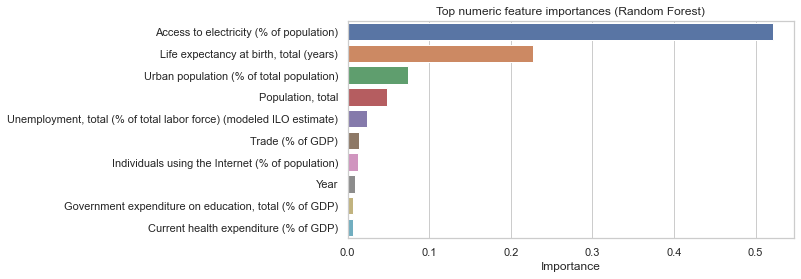

In [29]:
# Plot the most important NUMERIC indicators (more interpretable than country IDs)
fi_num = fi[fi.index.isin(num_cols)].head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=fi_num.values, y=fi_num.index, orient="h")
plt.title("Top numeric feature importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

### Interpreting feature importance

Among numeric indicators, **access to electricity**, **life expectancy**, and
**urban population share** emerge as the most influential features for prediction.

It is important to note that Random Forest feature importance reflects how useful
a variable is for prediction within this dataset. Because many development indicators
are correlated with each other, importance can concentrate on a small number of
features. These results should therefore be interpreted as **predictive associations**
rather than causal effects.

## 6) Creative Predictive Scenario (required)

Scenario:
> Starting from a typical country profile, what happens to predicted GDP per capita if
internet usage and electricity access increase, and health spending increases slightly?

We create a baseline row using median/mode values and then apply the scenario changes.
This is an illustrative prediction, not a causal estimate.

In [32]:
# ---- Build baseline row ----
baseline_row = pd.DataFrame([{
    col: (X_train[col].median() if col in num_cols else X_train[col].mode().iloc[0])
    for col in X_train.columns
}])

# Ensure exact column order match
baseline_row = baseline_row[X_train.columns]

# ---- Apply scenario shocks on a copy ----
improved_row = baseline_row.copy()

def bump(col, delta, cap=None):
    """
    Increases a selected feature value in the improved_row DataFrame by a
    specified absolute amount, with an optional upper cap.

    This function is used to simulate improvement scenarios by incrementally
    adjusting a single indicator (e.g., electricity access or school enrollment)
    for one observation while keeping all other features unchanged.

    Parameters
    ----------
    col : str
        Column name in improved_row to be adjusted.
    delta : float
        Absolute amount to add to the column value.
    cap : float, optional
        Maximum allowable value for the column after adjustment.
        If provided, the updated value is capped at this level.

    Returns
    -------
    None
        The function modifies improved_row in place.
    """
    if col in improved_row.columns and pd.notna(improved_row.loc[0, col]):
        improved_row.loc[0, col] = improved_row.loc[0, col] + delta
        if cap is not None:
            improved_row.loc[0, col] = min(cap, improved_row.loc[0, col])

bump("Individuals using the Internet (% of population)", 20, cap=100)
bump("Access to electricity (% of population)", 15, cap=100)
bump("Current health expenditure (% of GDP)", 1.5, cap=None)

# ---- Predict ----
base_pred_log = pipe.predict(baseline_row)[0]
imp_pred_log  = pipe.predict(improved_row)[0]

base_pred = 10 ** base_pred_log
imp_pred  = 10 ** imp_pred_log

print(f"Baseline predicted GDP per capita: ${base_pred:,.0f}")
print(f"Improved predicted GDP per capita: ${imp_pred:,.0f}")
print(f"Predicted change: {((imp_pred / base_pred) - 1) * 100:.1f}%")

Baseline predicted GDP per capita: $4,302
Improved predicted GDP per capita: $7,926
Predicted change: 84.3%


### Scenario interpretation

In the illustrative scenario, increasing internet usage, electricity access,
and health spending for a typical country profile raises the predicted GDP per capita
from approximately **$4,300** to **$7,900**, an increase of about **84%**.

This scenario does not represent a policy recommendation or causal estimate.
Instead, it demonstrates how the trained model can be used to explore
“what-if” questions and how strongly these development indicators tend to
move together with economic output in the data.

## 7) Conclusions

- **Q1:** The strongest associations with GDP per capita can be identified via Spearman correlation and supported by model importances.
- **Q2:** Connectivity (internet usage) and infrastructure (electricity access) show clear positive relationships with GDP per capita.
- **Q3:** Outliers can be identified using a transparent heuristic on a year with sufficient data coverage.
- **Q4:** A Random Forest model predicts GDP per capita accurately on held-out data and can be used for an illustrative “what-if” scenario.

**Limitations**
- Observational patterns do not imply causation.
- Feature importances reflect predictive utility and can be affected by correlated features.
- Country-code features capture persistent country differences and improve prediction.

**Next steps**
- Use time-based splitting (train early years, test later years).
- Compare with a simpler linear model for interpretability.